ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

# **1. Description: Why the Cleaning was Needed**
Before performing any analysis, an inspection of the AB_NYC_2019.csv dataset revealed several issues that would lead to inaccurate results if left unaddressed:

Missing Values: The columns reviews_per_month and last_review have over 10,000 missing values. This happens for listings that have never received a review. If we don't fix this, these listings might be ignored in our calculations.

Logical Data Errors (Outliers): There are 11 listings with a price of $0. Since an Airbnb listing cannot be free, these are likely data entry errors that would skew our average price calculations.

Incorrect Formats: The last_review column is currently stored as a generic "object" (text) instead of a "datetime" format. This makes it impossible to perform any time-based analysis without conversion.

Incomplete Strings: A few listings are missing a name or host_name. While minor, these should be filled with a placeholder like "Unknown" for cleaner presentation.



In [80]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [62]:
# Load Dataset
df = pd.read_csv("/content/AB_NYC_2019.csv")

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [78]:
# Check the dimensions of the dataset
dimensions = df.shape
print(f"The dataset has {dimensions[0]} rows and {dimensions[1]} columns.")

The dataset has 48895 rows and 16 columns.


# **2. EDA Data Cleaning Steps**

1: Handling Missing Names and Host Names

Reason: Some listings are missing names or host names. Filling them ensures every row has a label for identification.

Screenshots of before and after handling missing Names and Host Names
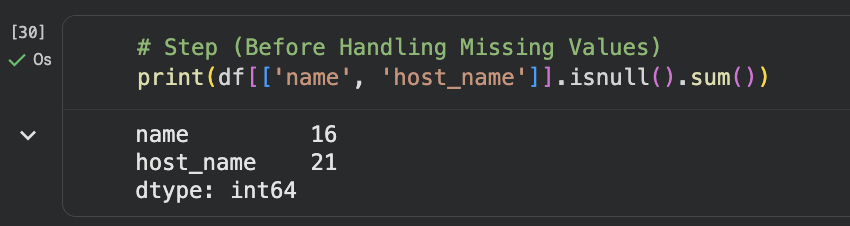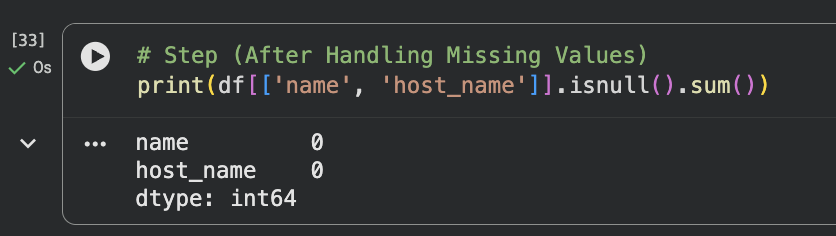

In [54]:
# Step (Before and After Handling Missing Values)
print(df[['name', 'host_name']].isnull().sum())

name         0
host_name    0
dtype: int64


In [53]:
# For fixing the missing values
df['name'].fillna("Unknown", inplace=True)
df['host_name'].fillna("Unknown", inplace=True)

2: Handling Missing Review Data

Reason: Listings with 0 reviews have NaN in the reviews_per_month column. We change this to 0.0 so we can perform mathematical calculations.

Screenshots of before and after handling Missing Review Data
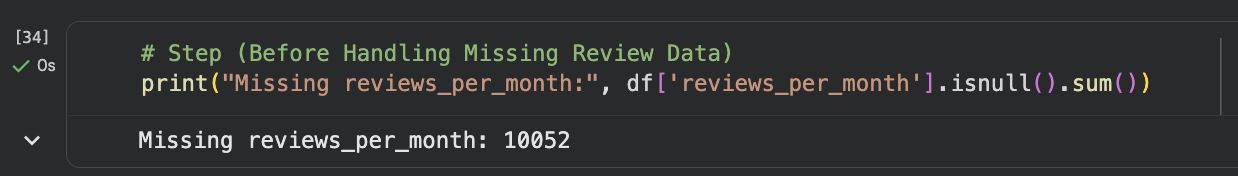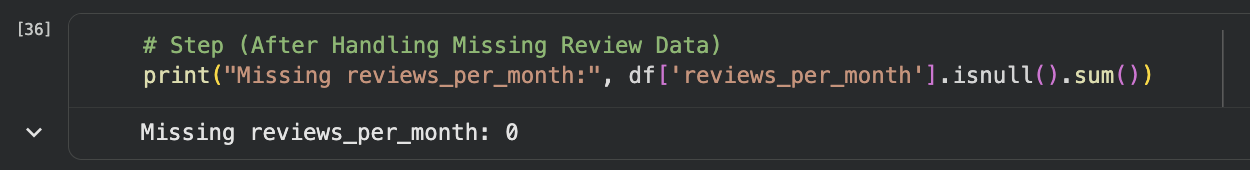

In [56]:
# Step (Before and After Handling Missing Review Data)
print("Missing reviews_per_month:", df['reviews_per_month'].isnull().sum())

Missing reviews_per_month: 0


In [55]:
# For fixing the missing values
df['reviews_per_month'].fillna(0, inplace=True)

/tmp/ipykernel_3350/2635204819.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0, inplace=True)


3: Handling Incorrect Price Data (Zero Prices)

Reason: A price of $0 is a data entry error. Removing these rows ensures our average price and price trends are accurate.

Screenshot of Handling Incorrect Price Data
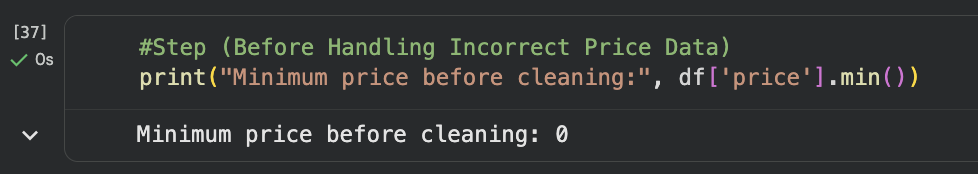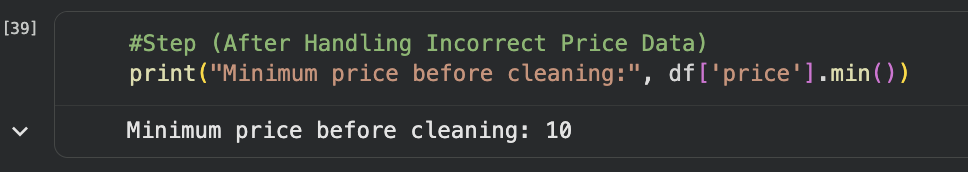

In [58]:
#Step (After Handling Incorrect Price Data)
print("Minimum price before cleaning:", df['price'].min())

Minimum price before cleaning: 10


In [57]:
# For fixing the missing values
df = df[df['price'] > 0]

4: Correcting Column Formats (Date Type)

Reason: The last_review column is a "string" (object). We need to convert it to a "datetime" format so the computer understands it as a date.

Screenshots of Correcting Column Formats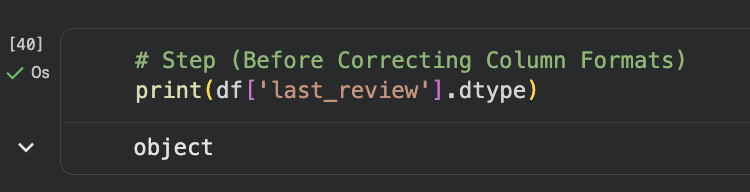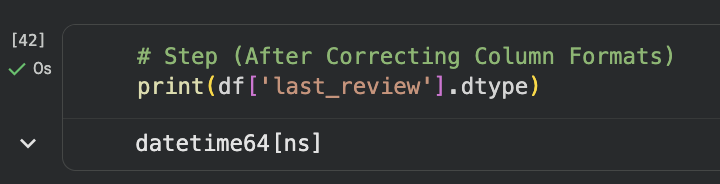

In [60]:
# Step (After Correcting Column Formats)
print(df['last_review'].dtype)

datetime64[ns]


In [59]:
# For fixing the column format
df['last_review'] = pd.to_datetime(df['last_review'])

5: Final Check (Total Cleanliness)
Reason: This is the final proof that the entire dataset has been cleaned.

Screenshots of the dataset before and after cleaning
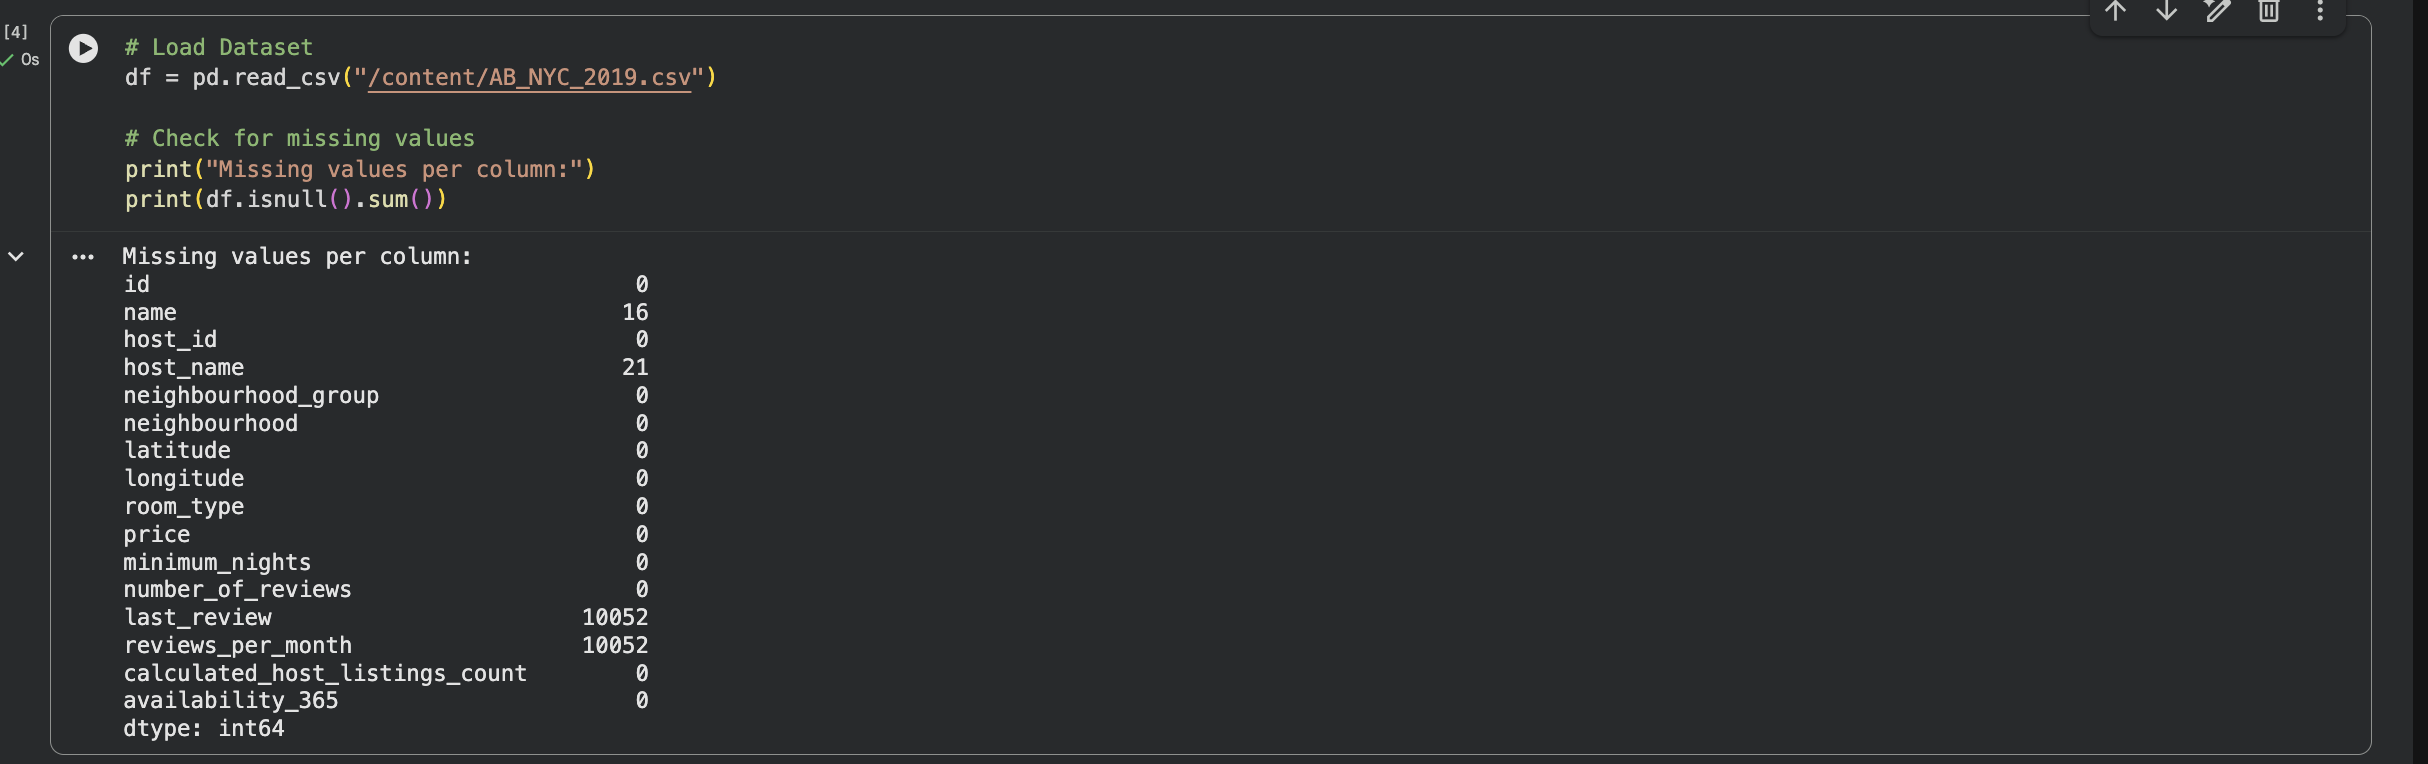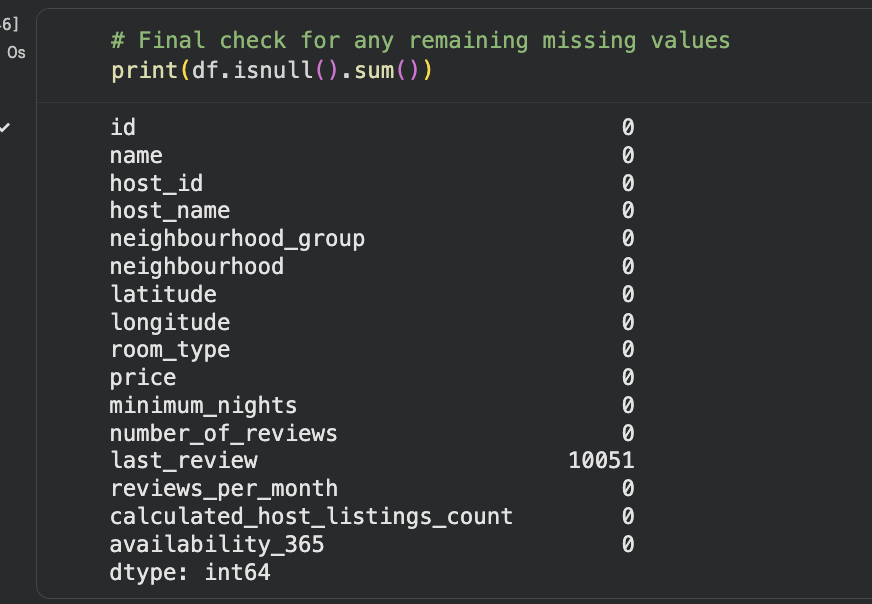

In [61]:
# Final check for any remaining missing values
print(df.isnull().sum())

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10051
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


# **3. Visualization and Insights**

Plot 1: Distribution of Listings by Borough

Why this visualization? I chose a Bar Chart to easily compare the volume of Airbnb activity across the five boroughs.

Insights & Patterns: Manhattan and Brooklyn have the highest number of listings, representing the majority of the market. Staten Island has the lowest density.

What can be learned? Airbnb activity is heavily concentrated in the most urban and tourist-heavy areas of New York City.

/tmp/ipykernel_3350/3144088661.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='neighbourhood_group', palette='viridis', order=df['neighbourhood_group'].value_counts().index)


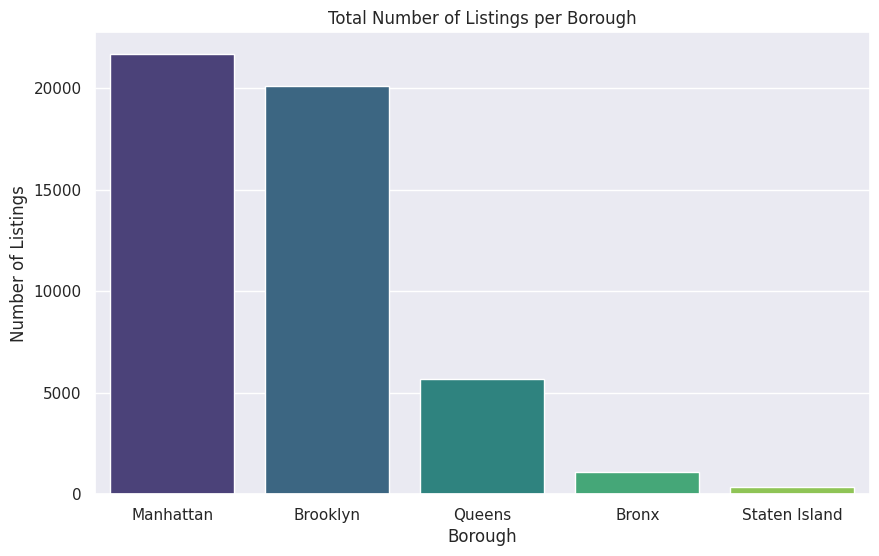

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='neighbourhood_group', palette='viridis', order=df['neighbourhood_group'].value_counts().index)
plt.title('Total Number of Listings per Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Listings')
plt.show()

- Shows how shipment sizes are distributed
- Right skew = many small shipments, few large ones

Plot 2: Room Type Preferences

Why this visualization? A Pie Chart is ideal for showing how the "whole" market is divided into parts (proportions).

Insights & Patterns: "Entire home/apt" and "Private room" dominate the market at nearly 98% combined. Shared rooms are very rare (around 2%).

What can be learned? Travelers in NYC prefer privacy and are willing to pay for separate rooms rather than sharing spaces.


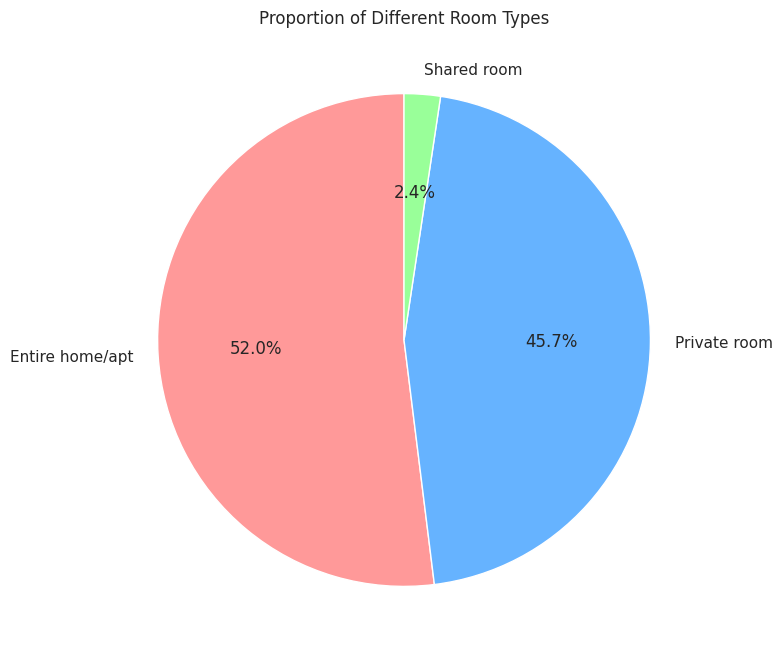

In [66]:
plt.figure(figsize=(8,8))
df['room_type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=90)
plt.title('Proportion of Different Room Types')
plt.ylabel('')
plt.show()

Plot 3: Price Distribution (Listings < $500)

Why this visualization? A Histogram with a KDE (line) shows where most prices fall and helps identify the "normal" range. I filtered out extreme outliers (> $500) to make the main trend visible.

Insights & Patterns: The distribution is "right-skewed." Most listings are clustered between $50 and $150.

What can be learned? Despite NYC's high cost of living, there is a significant supply of mid-range, affordable Airbnb options.

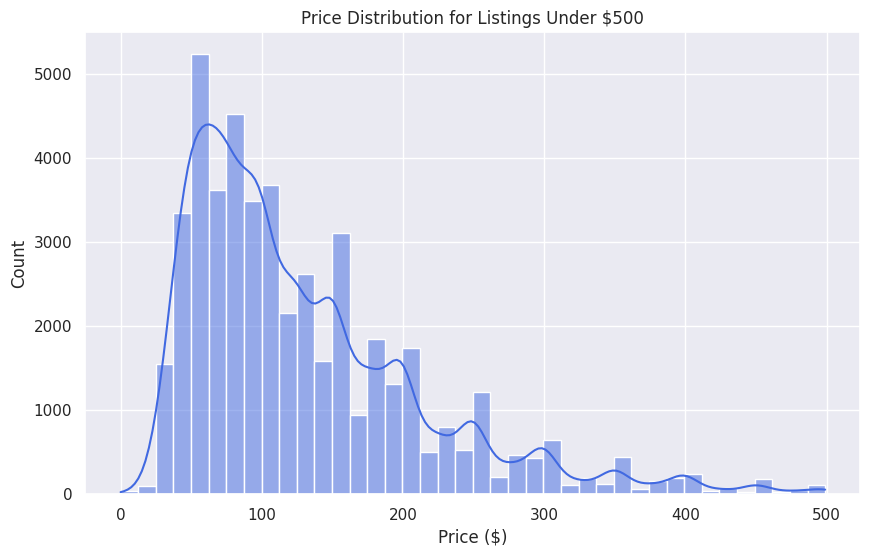

In [67]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['price'] < 500]['price'], bins=40, kde=True, color='royalblue')
plt.title('Price Distribution for Listings Under $500')
plt.xlabel('Price ($)')
plt.show()

Plot 4: Average Price per Borough

Why this visualization? This bar chart compares the average cost directly, which is more useful for travelers than just knowing the number of listings.

Insights & Patterns: Manhattan is the most expensive borough by far, while the Bronx is the most budget-friendly.

What can be learned? Geography is the strongest predictor of price in the NYC rental market.

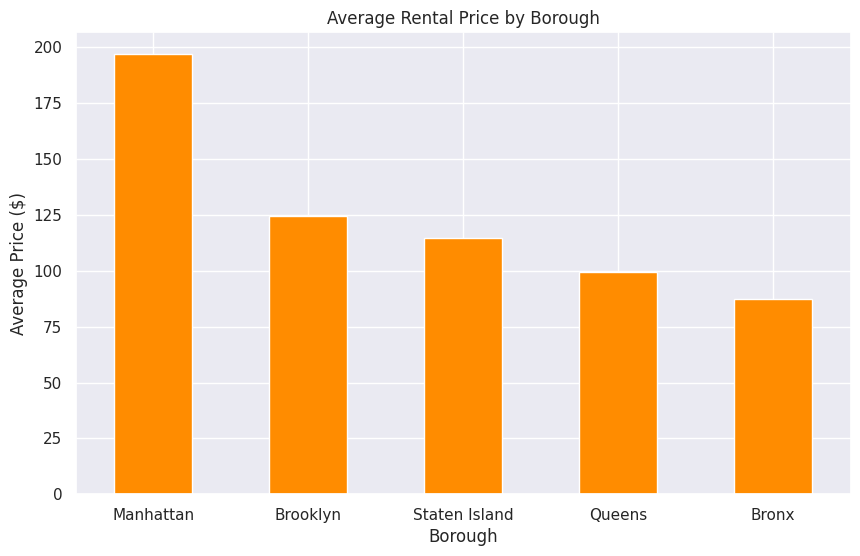

In [68]:
plt.figure(figsize=(10,6))
avg_price = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
avg_price.plot(kind='bar', color='darkorange')
plt.title('Average Rental Price by Borough')
plt.ylabel('Average Price ($)')
plt.xlabel('Borough')
plt.xticks(rotation=0)
plt.show()

Plot 5: Price Range by Room Type

Why this visualization? A Box Plot shows the "spread" of prices, including the median and the range, for different categories.

Insights & Patterns: Entire homes have a much higher median price and a larger variance compared to private rooms.

What can be learned? Upgrading from a "Private Room" to an "Entire Home" roughly doubles the expected cost.

/tmp/ipykernel_3350/709574733.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['price'] < 500], x='room_type', y='price', palette='Set2')


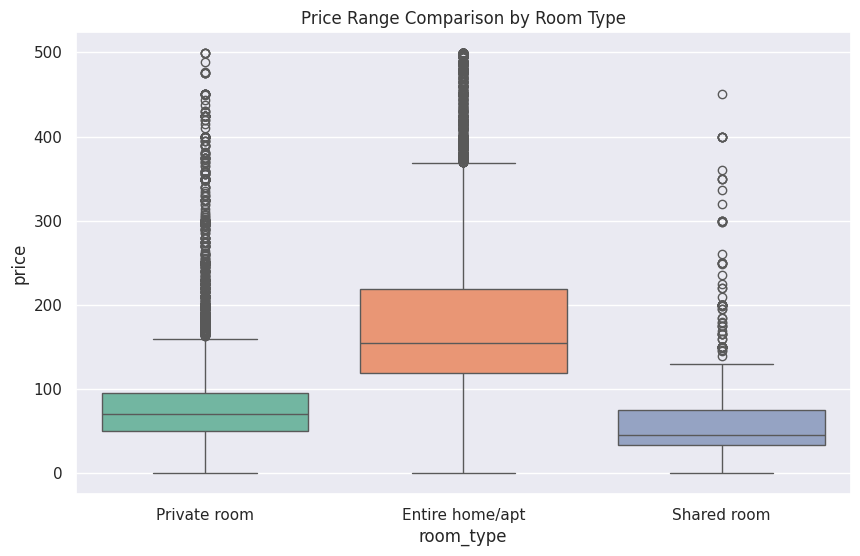

In [69]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[df['price'] < 500], x='room_type', y='price', palette='Set2')
plt.title('Price Range Comparison by Room Type')
plt.show()

Plot 6: Geographic Map of Listings

Why this visualization? Since we have Latitude and Longitude, a Scatter Plot allows us to "draw" the city map and see exactly where listings cluster.

Insights & Patterns: The highest density is in Manhattan and the western parts of Brooklyn, following the major subway lines.

What can be learned? Airbnb availability is tied to transit accessibility and proximity to the city center.

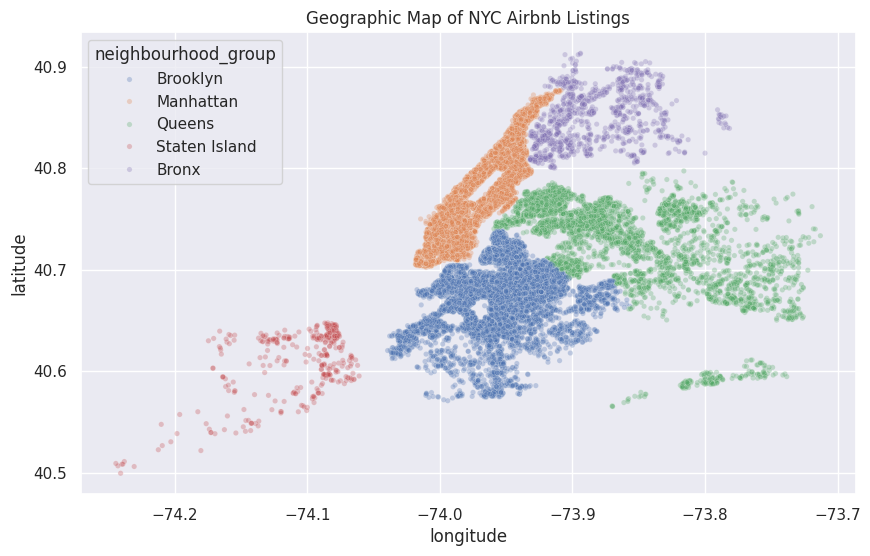

In [70]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='neighbourhood_group', alpha=0.3, s=15)
plt.title('Geographic Map of NYC Airbnb Listings')
plt.show()

Plot 7: Top 10 Most Popular Neighbourhoods

Why this visualization? A Horizontal Bar Chart is best for displaying long names (like neighborhood names) without them overlapping.

Insights & Patterns: Williamsburg (Brooklyn) and Bedford-Stuyvesant are the top two hubs for Airbnb in the entire city.

What can be learned? Certain neighborhoods have become "Airbnb hotspots," which could have social and economic impacts on local residents.

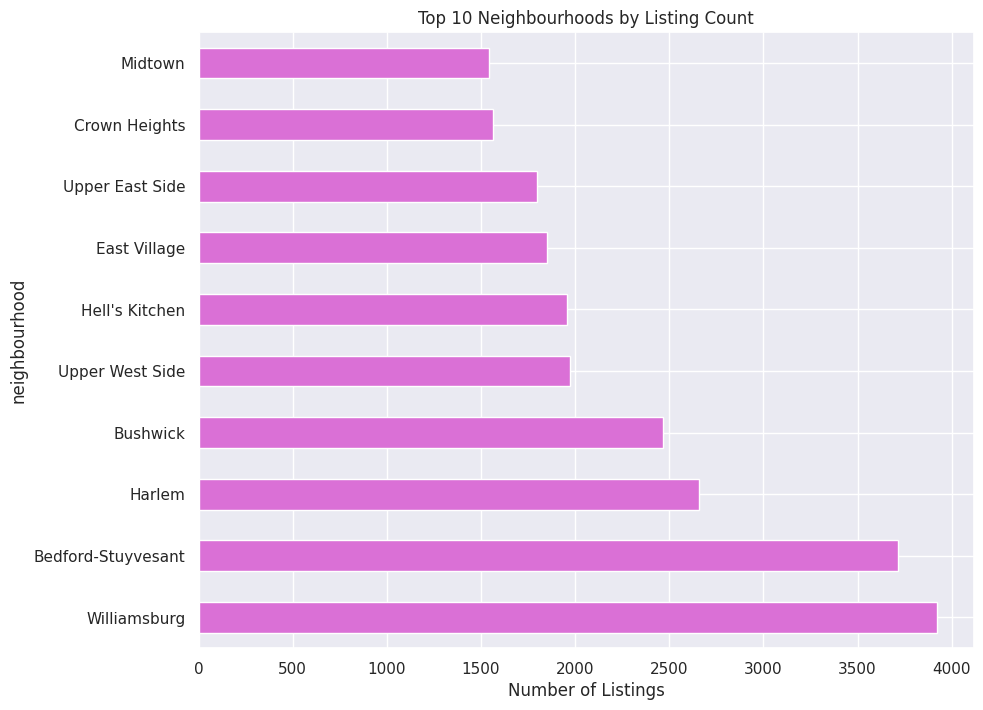

In [71]:
plt.figure(figsize=(10,8))
df['neighbourhood'].value_counts().head(10).plot(kind='barh', color='orchid')
plt.title('Top 10 Neighbourhoods by Listing Count')
plt.xlabel('Number of Listings')
plt.show()

Plot 8: Correlation Heatmap

Why this visualization? A Heatmap shows if one variable (like price) is related to another (like number of reviews).

Insights & Patterns: There is a low correlation between price and reviews, meaning expensive places don't necessarily get fewer reviews.

What can be learned? Booking decisions are complex and not based solely on price or location alone.

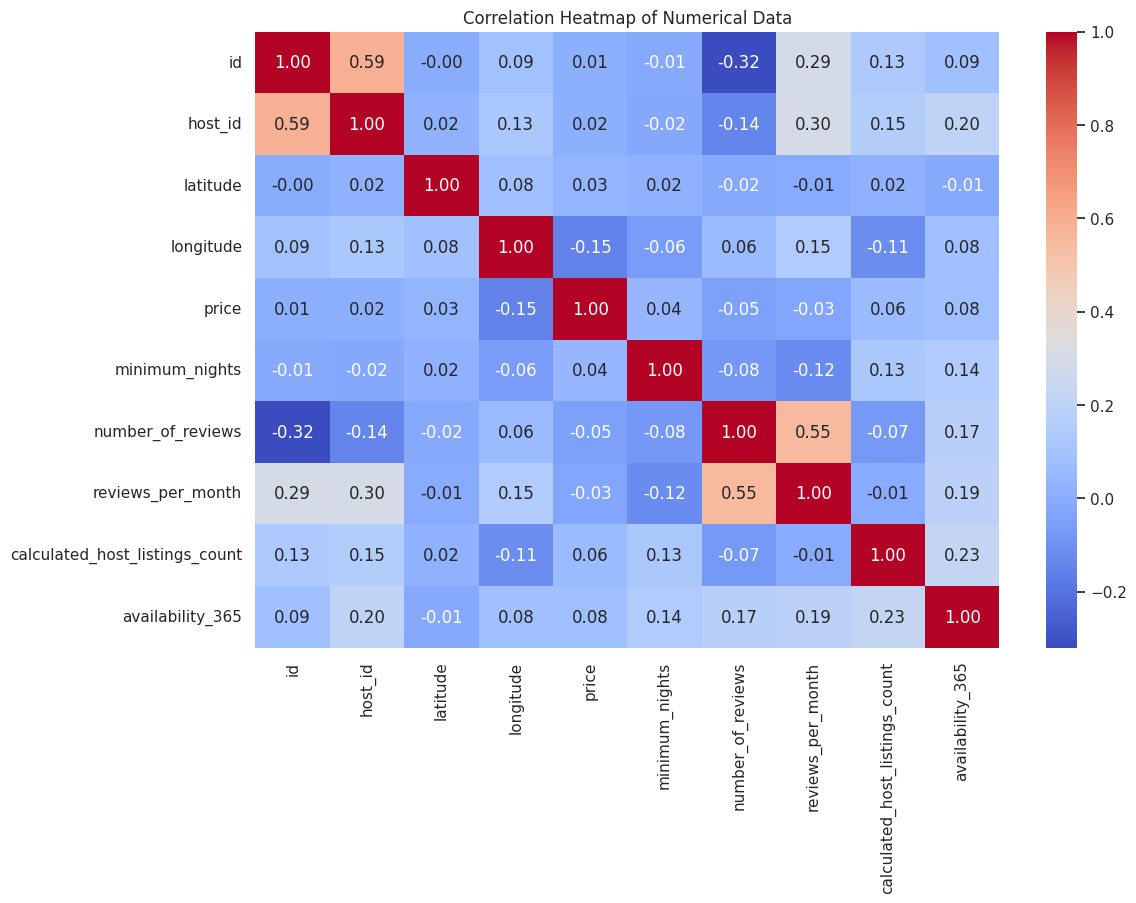

In [72]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Data')
plt.show()

Plot 9: Number of Reviews vs. Price

Why this visualization? A Scatter Plot helps us see if there is a trend between how much a place costs and how "active" it is in terms of reviews.

Insights & Patterns: The most reviewed listings are consistently in the lower price range ($50-$150).

What can be learned? More affordable listings tend to have a higher guest turnover and higher engagement.

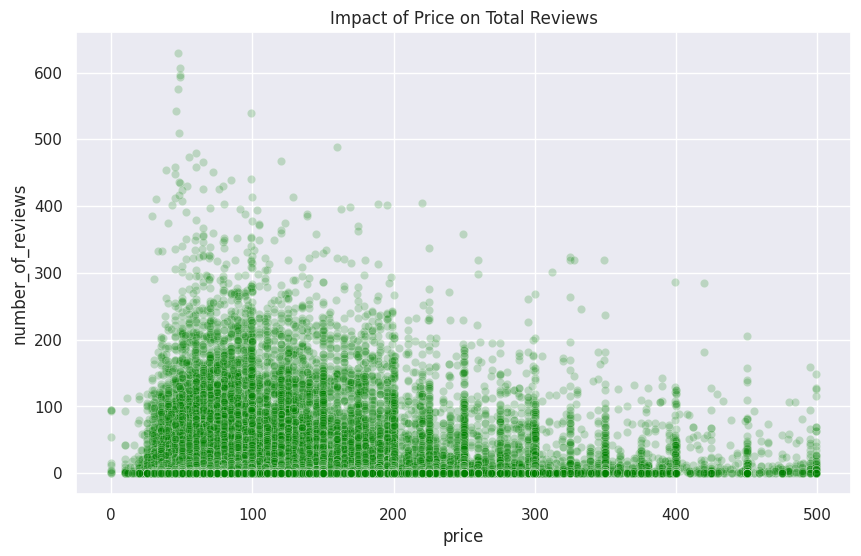

In [73]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df[df['price'] < 500], x='price', y='number_of_reviews', alpha=0.2, color='green')
plt.title('Impact of Price on Total Reviews')
plt.show()

Plot 10: Average Availability per Borough

Why this visualization? This bar chart shows how often listings are "open" for business in different areas.

Insights & Patterns: Staten Island and the Bronx have higher availability than Manhattan or Brooklyn.

What can be learned? Listings in the most popular boroughs (Manhattan/Brooklyn) are likely booked more often, leading to lower year-round availability.

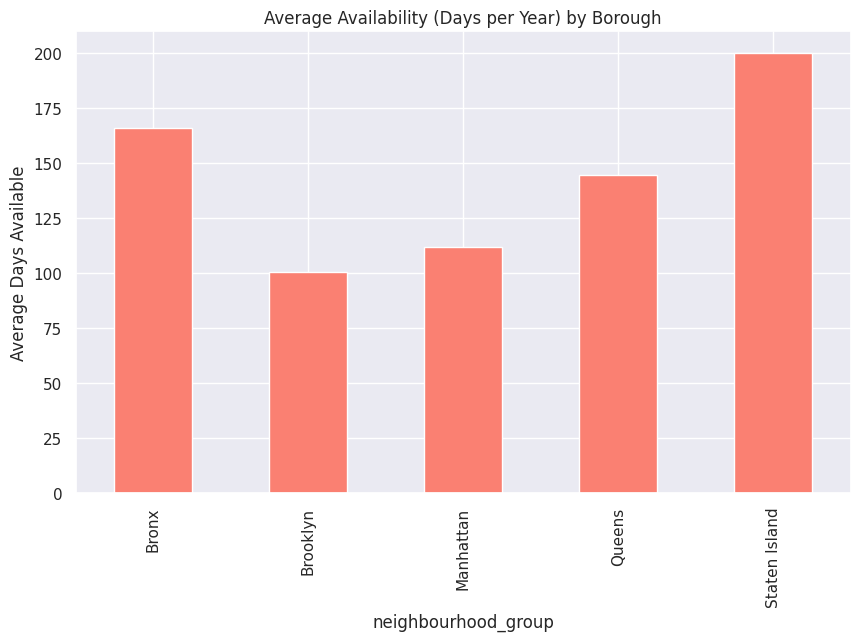

In [74]:
plt.figure(figsize=(10,6))
df.groupby('neighbourhood_group')['availability_365'].mean().plot(kind='bar', color='salmon')
plt.title('Average Availability (Days per Year) by Borough')
plt.ylabel('Average Days Available')
plt.show()

# **4. Time-Based Analysis**

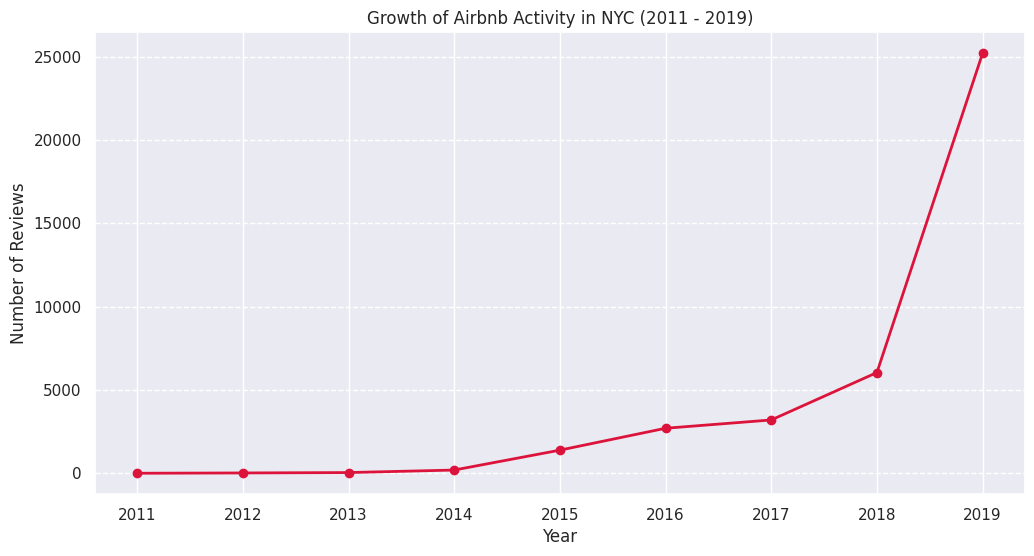

/tmp/ipykernel_3350/3153149140.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_time, x='review_month', palette='coolwarm')


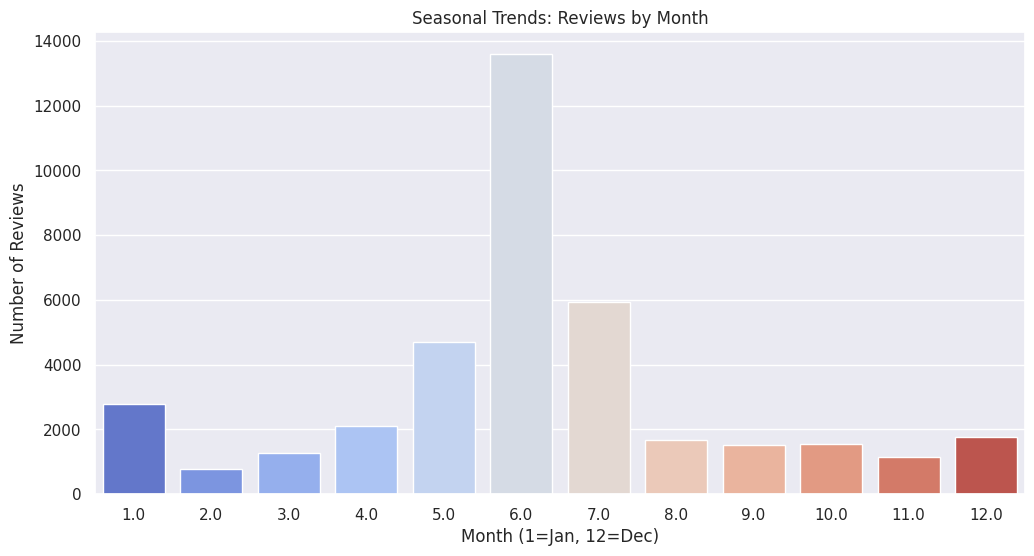

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_time = pd.read_csv('AB_NYC_2019.csv')


df_time['last_review'] = pd.to_datetime(df_time['last_review'])


df_time['review_year'] = df_time['last_review'].dt.year
df_time['review_month'] = df_time['last_review'].dt.month

# Plot 11: Growth Over the Years
plt.figure(figsize=(12,6))
df_time['review_year'].value_counts().sort_index().plot(kind='line', marker='o', color='crimson', linewidth=2)
plt.title('Growth of Airbnb Activity in NYC (2011 - 2019)')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--')
plt.show()

# Plot 12: Monthly Seasonality
plt.figure(figsize=(12,6))
sns.countplot(data=df_time, x='review_month', palette='coolwarm')
plt.title('Seasonal Trends: Reviews by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Number of Reviews')
plt.show()

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
